## Import Library

In [346]:
import pandas as pd
import numpy as np

# visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# model
from lightgbm import LGBMClassifier

# evaluasi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

## Load Dataset

In [347]:
df = pd.read_csv("loan_data.csv")

# Hapus kolom ID yang tidak relevan
df = df.drop(columns=['Loan_ID'])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Eksplorasi Data & Missing Value

In [348]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nDistribusi target Loan_Status:")
print(df['Loan_Status'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    str    
 1   Married            611 non-null    str    
 2   Dependents         599 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      582 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 57.7 KB

Missing values:
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantInc

## Handling Missing Value

In [349]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    if col != 'Loan_Status':
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values setelah handling:")
print(df.isnull().sum())

Missing values setelah handling:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_30268/2599548430.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


## Encoding Kategorikal

In [350]:
le = LabelEncoder()

cat_cols = [col for col in df.select_dtypes(include='object').columns if col != 'Loan_Status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Encode target dengan ubah Y/N ke 1/0
df['Loan_Status'] = (df['Loan_Status'] == 'Y').astype(int)

print("Distribusi target setelah encoding:")
print(df['Loan_Status'].value_counts())
print(f"\nJumlah kelas unik: {df['Loan_Status'].nunique()} → harus = 2")

Distribusi target setelah encoding:
Loan_Status
1    422
0    192
Name: count, dtype: int64

Jumlah kelas unik: 2 → harus = 2


/tmp/ipykernel_30268/2009677615.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [col for col in df.select_dtypes(include='object').columns if col != 'Loan_Status']


## Handling Outlier

In [351]:
exclude_outlier_cols = ['Credit_History', 'Loan_Amount_Term', 'Loan_Status',
                        'Gender', 'Married', 'Dependents', 'Education',
                        'Self_Employed', 'Property_Area']

def remove_outlier(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in df.select_dtypes(include=np.number).columns:
    if col not in exclude_outlier_cols:
        df = remove_outlier(df, col)

print(f"Jumlah data setelah outlier removal: {len(df)}")
print("Distribusi target setelah outlier removal:")
print(df['Loan_Status'].value_counts())

Jumlah data setelah outlier removal: 520
Distribusi target setelah outlier removal:
Loan_Status
1    362
0    158
Name: count, dtype: int64


## Feature Construction

In [352]:
# Membuat Fitur Baru
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

df['LoanAmount_Income_Ratio'] = df['LoanAmount'] / (df['Total_Income'] + 1)

print("Kolom setelah feature construction:")
print(df.columns.tolist())

Kolom setelah feature construction:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'Total_Income', 'LoanAmount_Income_Ratio']


## Split Data

In [354]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# FIX: Gunakan stratify=y agar distribusi kelas terjaga di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
# print("Distribusi target train:", y_train.value_counts().to_dict())
# print("Distribusi target test:", y_test.value_counts().to_dict())

Train size: 416, Test size: 104


### Aktifkan Salah 1 Saja Metode Scaling

## Z Score

In [355]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)  
# X_test = scaler.transform(X_test)        

## Min Max Scaling

In [356]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

## Decimal Scaling

In [357]:
# import numpy as np

# def decimal_scaling(X):
#     X_scaled = X.copy()
    
#     for col in X.columns:
#         max_val = X[col].abs().max()
#         j = len(str(int(max_val)))  # jumlah digit
        
#         X_scaled[col] = X[col] / (10 ** j)
    
#     return X_scaled

# # pakai
# X_train_scaled = decimal_scaling(X_train)
# X_test_scaled = decimal_scaling(X_test)

## Log Scaling

In [358]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

for col in X_train.columns:
    X_train_scaled[col] = np.log1p(X_train[col])
    X_test_scaled[col] = np.log1p(X_test[col])

## Model LightGBM

In [359]:
model = LGBMClassifier(random_state=42, verbose=-1)
# model.fit(X_train, y_train)
model.fit(X_train_scaled, y_train)

print("Model berhasil dilatih.")

Model berhasil dilatih.


## Evaluasi Model

In [360]:
y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ditolak (0)', 'Disetujui (1)']))

Accuracy : 0.8077
Precision: 0.8171
Recall   : 0.9306
F1 Score : 0.8701

Classification Report:


               precision    recall  f1-score   support

  Ditolak (0)       0.77      0.53      0.63        32
Disetujui (1)       0.82      0.93      0.87        72

     accuracy                           0.81       104
    macro avg       0.79      0.73      0.75       104
 weighted avg       0.80      0.81      0.80       104



## Boxplot

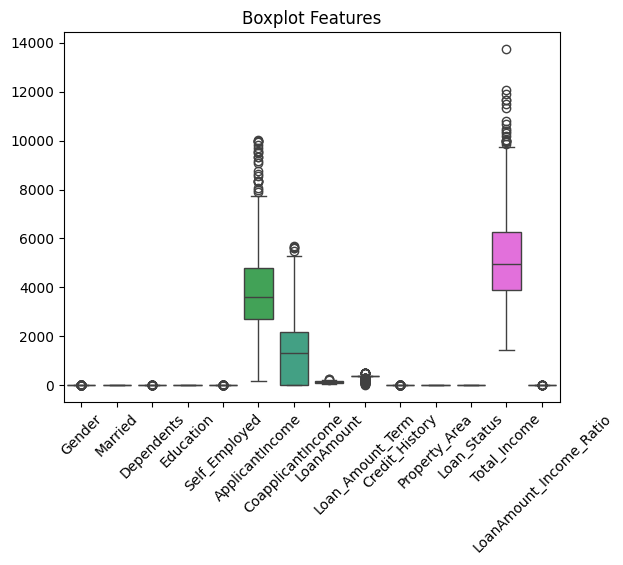

In [361]:
plt.figure()
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Boxplot Features")
plt.show()

## HeatMap

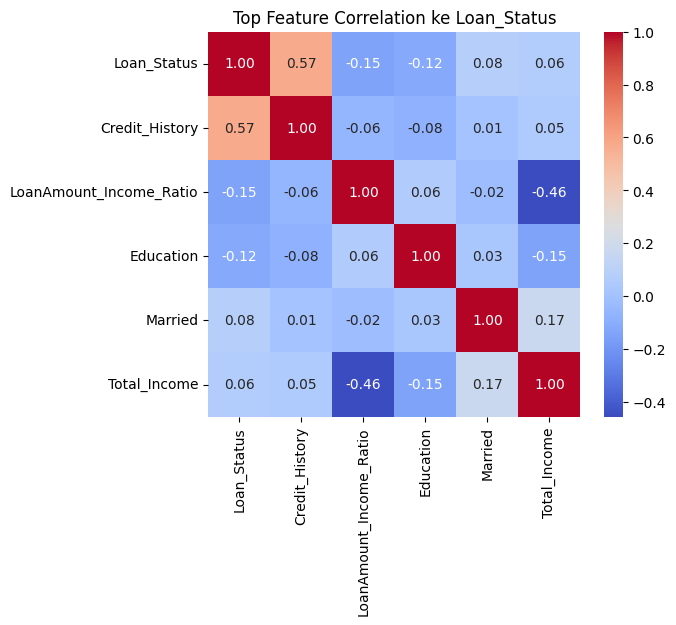

In [362]:
# plt.figure()
# sns.heatmap(df.corr(numeric_only=True), annot=True)
# plt.title("Correlation Heatmap")
# plt.show()

corr = df.corr(numeric_only=True)

# ambil top fitur terhadap target
top_features = corr['Loan_Status'].abs().sort_values(ascending=False).head(6).index

corr_top = df[top_features].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_top, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Top Feature Correlation ke Loan_Status")
plt.show()

